# Chapter 14 Bayesian Experimentation for A/B Testing: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-14-bayesian-ab-testing-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

At 1,000 visitors per variant, a two-proportion z-test on a checkout-button redesign returns a
p-value of 0.126. That test asks a narrow question: whether two observed conversion rates
differ by more than chance alone would plausibly explain.

Under the conventional 0.05 threshold, the 0.126 result is not significant: the frequentist
framework says stop, you cannot reject the null.

A Bayesian model fit to the same 2,000 visitors says the redesign has a 93.7% chance of beating
the original. If that 93.7% turns out to be wrong, shipping it now carries an average cost of
0.038 percentage points of conversion.

Both statements are correct. They are answers to different questions, and knowing which
question you are asking is most of what this part of the book is about.

Part 1 introduced Bayes' theorem and frequentist hypothesis testing as two separate tools. This
part treats Bayesian inference as a full alternative to the hypothesis-testing machinery from
Chapter 2.

It gives a way to run an experiment, watch it while it runs, and make a shipping decision
without waiting for a p-value to cross a line someone picked in advance.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from scipy import stats

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(101)

## Priors: how much to assume before the data arrives

Each curve puts the same 10% central belief on the x-axis (conversion rate, 0% to 40%) but spreads that belief differently: the uninformative prior spans almost the full range, while the highly informative prior shown here, built from about 10,000 pseudo-observations, concentrates nearly all its density within a percentage point of 10%. The stronger the prior, the more data it takes to move it.

In [4]:
def fig_prior_shapes() -> go.Figure:
    priors = [(1, 1), (11, 91), (50, 450), (200, 1800), (1000, 9000)]
    labels = ["Beta(1,1) uninformative", "Beta(11,91) weakly informative (~100 obs.)",
              "Beta(50,450) more confident (~500 obs.)",
              "Beta(200,1800) strongly informative (~2,000 obs.)",
              "Beta(1000,9000) highly informative (~10,000 obs.)"]
    x = np.linspace(0, 0.4, 400)
    x_list = x.tolist()
    frames = []
    for (a, b), label in zip(priors, labels):
        pdf = stats.beta.pdf(x, a, b)
        frames.append(
            go.Frame(
                name=label,
                data=[go.Scatter(x=x_list, y=pdf.tolist(), mode="lines", fill="tozeroy",
                                  line=dict(color="#4C78A8", width=2.5))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"mean = {a / (a + b):.1%}, pseudo-observations = {a + b - 2:.0f}",
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A prior expresses the same 10% central belief at five different strengths",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.4],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "prior: "},
            "steps": [
                # Short display labels on purpose: the full frame names (e.g.
                # "Beta(1000,9000) highly informative (~10,000 obs.)") overhang past
                # the plot's right margin at the slider's end positions and get
                # clipped by the plot boundary. Even the shortened "Beta(1000,9000)"
                # form still clipped by a couple of characters at the rightmost step,
                # so the label drops the "Beta" prefix too and the right margin grows
                # to give the last tick's centered text room to breathe. Frame names
                # stay unchanged below since the animate() call targets them by name.
                {"label": short, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f, short in zip(frames, ["(1,1)", "(11,91)", "(50,450)",
                                              "(200,1800)", "(1000,9000)"])
            ],
        }],
        margin=dict(t=60, l=60, r=60, b=50),
    )
    return fig

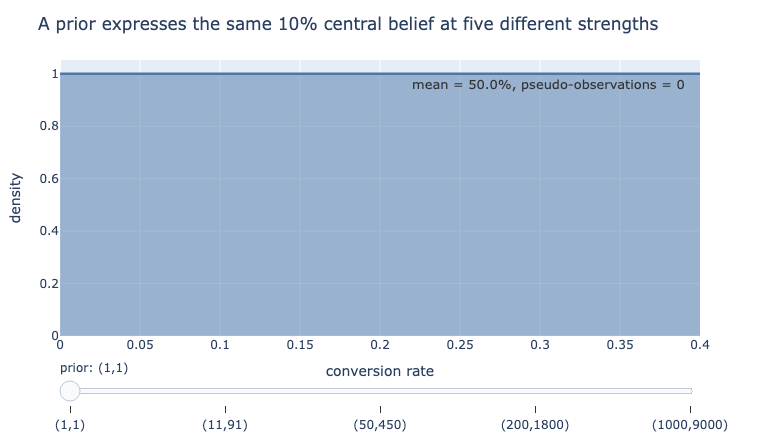

In [5]:
show(fig_prior_shapes())

## Beta-Binomial conjugacy

A single variant's posterior narrows and settles as observed visitors accumulate. Early swings are large; by a few thousand visitors, new data barely moves it.

In [6]:
def fig_posterior_update() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_rate = 0.10
    sample_sizes = [0, 25, 100, 500, 2000, 8000]
    x = np.linspace(0, 0.4, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        conv = RNG.binomial(n, true_rate) if n else 0
        a, b = prior_a + conv, prior_b + (n - conv)
        mean = a / (a + b)
        frames.append(
            go.Frame(
                name=str(n),
                data=[go.Scatter(x=x_list, y=stats.beta.pdf(x, a, b).tolist(), mode="lines",
                                  fill="tozeroy", line=dict(color="#4C78A8", width=3))],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"n = {n}, conversions = {conv}<br>"
                          f"posterior mean = {mean:.1%}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A single variant's Beta(1,1) posterior narrows and settles as visitors accumulate",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.4],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors observed: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

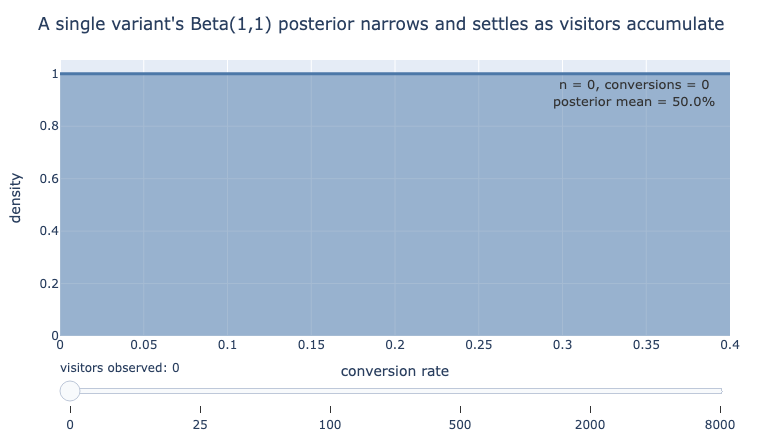

In [7]:
show(fig_posterior_update())

## Two variants, one decision

Variant A and Variant B posteriors separate as each group collects data. By a few thousand visitors per variant, the two curves barely overlap.

In [8]:
def fig_ab_overlay() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_a_rate, true_b_rate = 0.10, 0.125
    sample_sizes = [50, 200, 1000, 5000]
    x = np.linspace(0, 0.3, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        a_conv = RNG.binomial(n, true_a_rate)
        b_conv = RNG.binomial(n, true_b_rate)
        aa, ab = prior_a + a_conv, prior_b + (n - a_conv)
        ba, bb = prior_a + b_conv, prior_b + (n - b_conv)
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, aa, ab).tolist(), mode="lines",
                               name="Variant A posterior", line=dict(color="#4C78A8", width=3)),
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, ba, bb).tolist(), mode="lines",
                               name="Variant B posterior", line=dict(color="#E45756", width=3)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=f"A: {a_conv}/{n} conversions, B: {b_conv}/{n} conversions",
                    font=dict(size=12, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Variant A and Variant B posteriors separate as each group collects data",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.3],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors per variant: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

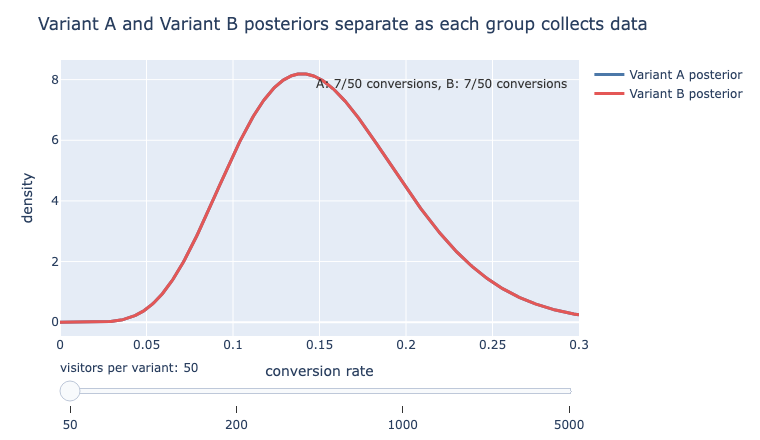

In [9]:
show(fig_ab_overlay())

## Expected loss as a stopping rule

Win probability and expected loss from choosing B, as the sample size grows. Expected loss stays a steadier guide than win probability when the sample is still small.

In [10]:
def fig_decision_metrics() -> go.Figure:
    prior_a, prior_b = 1, 1
    true_a_rate, true_b_rate = 0.10, 0.125
    sample_sizes = [50, 200, 500, 1000, 2000, 5000]
    n_samples = 200_000
    x = np.linspace(0, 0.3, 400)
    x_list = x.tolist()
    frames = []
    for n in sample_sizes:
        a_conv = RNG.binomial(n, true_a_rate)
        b_conv = RNG.binomial(n, true_b_rate)
        aa, ab = prior_a + a_conv, prior_b + (n - a_conv)
        ba, bb = prior_a + b_conv, prior_b + (n - b_conv)

        a_draws = RNG.beta(aa, ab, size=n_samples)
        b_draws = RNG.beta(ba, bb, size=n_samples)
        p_b_best = float(np.mean(b_draws > a_draws))
        expected_loss_b = float(np.mean(np.maximum(a_draws - b_draws, 0)))

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, aa, ab).tolist(), mode="lines",
                               name="Variant A posterior", line=dict(color="#4C78A8", width=2)),
                    go.Scatter(x=x_list, y=stats.beta.pdf(x, ba, bb).tolist(), mode="lines",
                               name="Variant B posterior", line=dict(color="#E45756", width=2)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"A: {a_conv}/{n}, B: {b_conv}/{n}<br>"
                          f"P(B beats A) = {p_b_best:.1%}<br>"
                          f"expected loss choosing B = {expected_loss_b:.4f}"),
                    font=dict(size=12, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Win probability and expected loss, computed from the same posteriors, as n grows",
        xaxis_title="conversion rate",
        yaxis_title="density",
        xaxis_range=[0, 0.3],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "visitors per variant: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

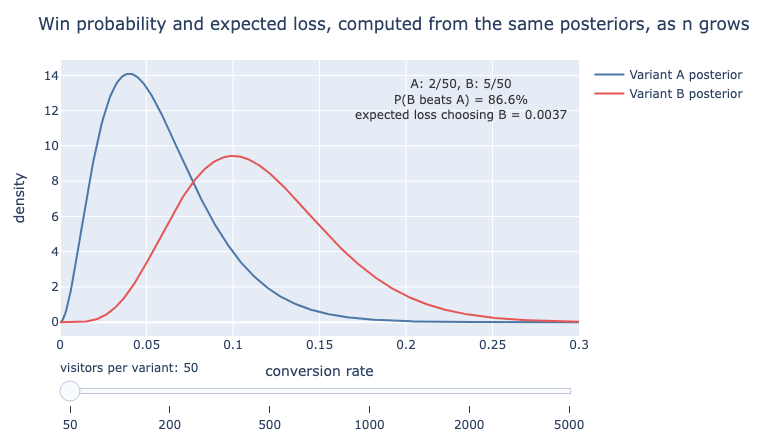

In [11]:
show(fig_decision_metrics())

## Continuous monitoring and the peeking problem

False-positive rate under a true null, as the number of times the test is checked grows. A single fixed-horizon check holds the nominal 5%; five checks push it past 14%.

In [12]:
def fig_peeking_problem() -> go.Figure:
    n_simulations = 3000
    max_n = 6000
    look_counts = [1, 2, 5, 10, 20, 40]
    rate = 0.10

    control = RNG.binomial(1, rate, size=(n_simulations, max_n))
    treatment = RNG.binomial(1, rate, size=(n_simulations, max_n))  # same rate: null is true
    control_cum = np.cumsum(control, axis=1)
    treatment_cum = np.cumsum(treatment, axis=1)

    frames = []
    for looks in look_counts:
        check_points = np.linspace(max_n // looks, max_n, looks).astype(int) - 1
        rejected = np.zeros(n_simulations, dtype=bool)
        for idx in check_points:
            n = idx + 1
            p1 = control_cum[:, idx] / n
            p2 = treatment_cum[:, idx] / n
            pooled = (control_cum[:, idx] + treatment_cum[:, idx]) / (2 * n)
            se = np.sqrt(pooled * (1 - pooled) * (2 / n)) + 1e-12
            z = (p2 - p1) / se
            rejected |= np.abs(z) > 1.96
        false_positive_rate = float(np.mean(rejected))
        frames.append(
            go.Frame(
                name=str(looks),
                data=[go.Bar(x=["False-positive rate"], y=[false_positive_rate],
                              marker_color="#E45756", width=[0.5],
                              text=[f"{false_positive_rate:.1%}"], textposition="outside")],
                layout=go.Layout(shapes=[dict(
                    type="line", x0=-0.5, x1=0.5, y0=0.05, y1=0.05,
                    line=dict(color="#333", width=1.5, dash="dash"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Checking a fixed-horizon significance test repeatedly inflates the "
              "false-positive rate above the nominal 5%",
        yaxis_title="false-positive rate under a true null",
        yaxis_range=[0, 0.5],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "number of times the test is checked: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=80, l=60, r=30, b=50),
    )
    return fig

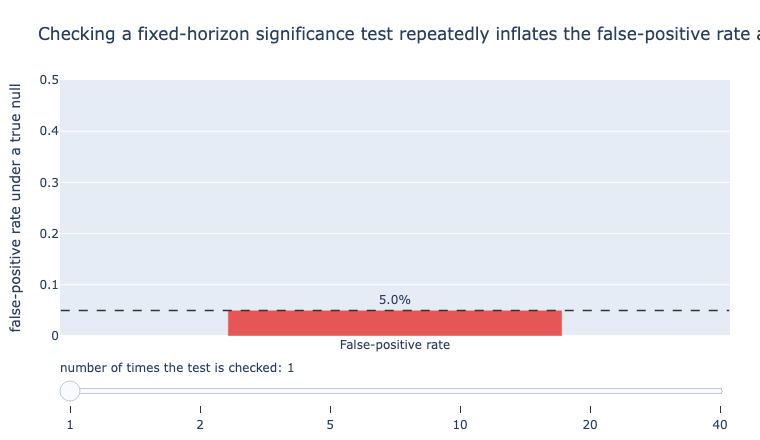

In [13]:
show(fig_peeking_problem())

## Beyond conversion rates

The average-order-value posterior narrows and slides from the \$42 prior toward the observed \$44.10 sample mean as converting visitors accumulate. Move the slider.

In [14]:
def fig_normal_normal_update() -> go.Figure:
    prior_mean, prior_sd = 42.0, 5.0
    prior_var = prior_sd**2
    sample_mean, sample_sd = 44.10, 18.0
    data_var = sample_sd**2

    sample_sizes = [0, 10, 50, 150, 500]
    x_grid = np.linspace(20, 60, 400)
    x_list = x_grid.tolist()

    prior_density = stats.norm.pdf(x_grid, loc=prior_mean, scale=prior_sd).tolist()

    frames = []
    for n in sample_sizes:
        tau_prior = 1.0 / prior_var
        tau_data = n / data_var
        tau_post = tau_prior + tau_data
        post_mean = (tau_prior * prior_mean + tau_data * sample_mean) / tau_post
        post_sd = np.sqrt(1.0 / tau_post)
        posterior_density = stats.norm.pdf(x_grid, loc=post_mean, scale=post_sd)
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=x_list, y=prior_density, mode="lines",
                               line=dict(color="#B7C7DB", width=2, dash="dot"),
                               name="prior: N(42, 5²)"),
                    go.Scatter(x=x_list, y=posterior_density.tolist(), mode="lines",
                               fill="tozeroy", line=dict(color="#4C78A8", width=2.5),
                               name="posterior"),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.98, y=0.95, xref="paper", yref="paper", showarrow=False,
                    xanchor="right",
                    text=(f"n = {n} converting visitors<br>"
                          f"posterior mean = ${post_mean:.2f}, posterior sd = ${post_sd:.2f}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A Normal prior on average order value narrows toward the observed "
              "$44.10 sample mean as n grows",
        xaxis_title="average order value ($)",
        yaxis_title="density",
        xaxis_range=[20, 60],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "converting visitors observed: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

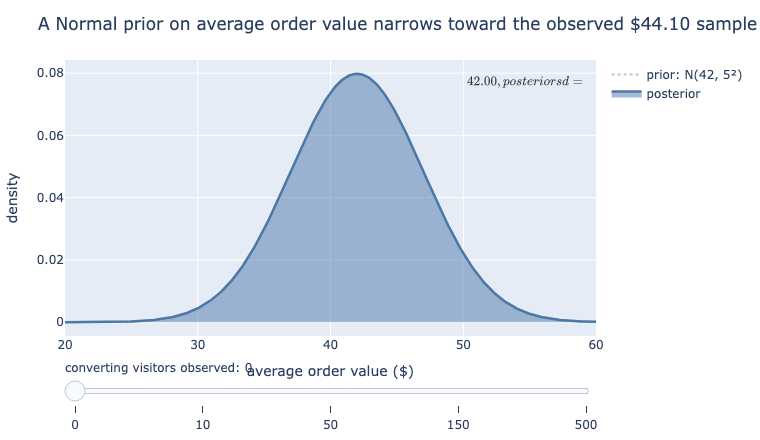

In [15]:
show(fig_normal_normal_update())